# Daily Orders Forecasting Using XGBoost

This notebook forecasts daily orders for the next 7 days using historical order data. The original dataset contains two columns: the date and the number of orders. Although the dataset is simple, additional calendar, lag, rolling, trend, holiday, and cyclical features are engineered to improve forecasting performance.

The objective is to build a short-term forecasting model that can help businesses estimate expected order volume and support planning for staffing, inventory, and daily operations.

## 1. Import Libraries

The required Python libraries are imported in this section. These libraries are used for data manipulation, feature engineering, model training, evaluation, visualization, holiday detection, and model interpretation.

In [53]:
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## 2. Load and Prepare Data

The dataset is loaded from a CSV file. The date column is converted to datetime format and used as the index of the time series. The order column is converted to numeric format and the data is sorted chronologically.

In [55]:
df = pd.read_csv("RecentOrders1.csv", sep=";")

df = df.rename(columns={
    "Aantal_Orders": "orders",
    "Laaddatum": "LoadingDate"
})

df["LoadingDate"] = pd.to_datetime(
    df["LoadingDate"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["LoadingDate"])
df = df.set_index("LoadingDate").sort_index()

df = df[["orders"]].copy()
df = df.asfreq("D")
df = df.dropna()

df["orders"] = df["orders"].astype(float)

print(df.head())
print(df.tail())

             orders
LoadingDate        
2023-01-01     18.0
2023-01-02    107.0
2023-01-03    136.0
2023-01-04    121.0
2023-01-05    133.0
             orders
LoadingDate        
2026-04-29    111.0
2026-04-30    117.0
2026-05-01     94.0
2026-05-02     62.0
2026-05-03     32.0


## 3. Basic Data Exploration

Before training the forecasting model, the daily order pattern is explored visually. This helps understand the overall trend, variation, and possible weekly patterns in the data.

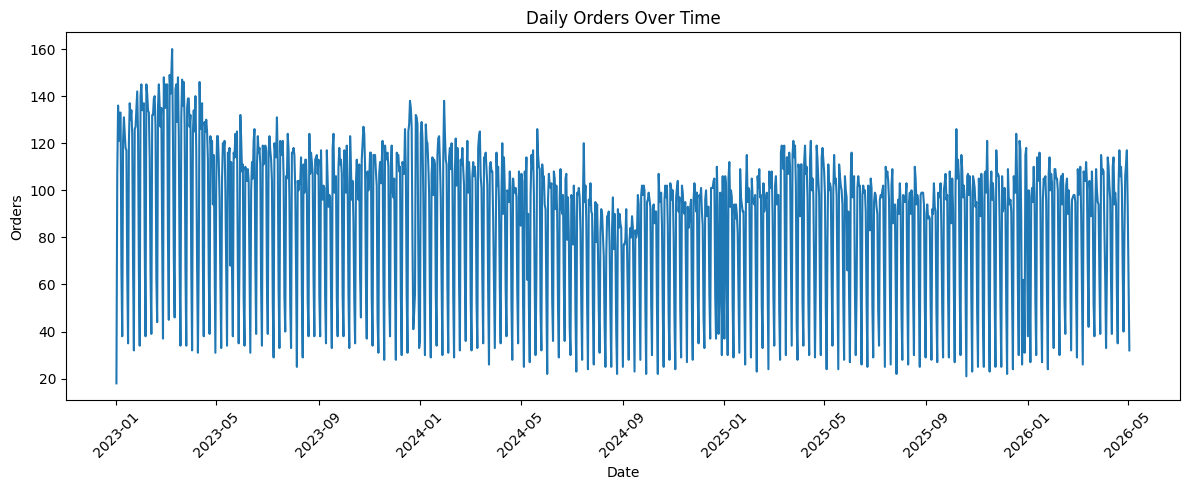

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["orders"])
plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Although the original dataset contains only the date and the number of orders, several predictive features are created from the historical time series. These features help the model capture weekly patterns, monthly effects, holidays, recent demand behavior, and short-term trends.

The engineered features include:

- Calendar features, such as day of week, week of year, month, year, and day of month.
- Weekend, Sunday, holiday, and end-of-month indicators.
- Cyclical date features using sine and cosine transformations.
- Lag features based on previous order values.
- Rolling statistics, such as rolling mean, standard deviation, minimum, and maximum.
- Trend and momentum features based on recent changes in order volume.

In [60]:
nl_holidays = holidays.Netherlands(
    years=list(range(df.index.min().year, df.index.max().year + 2))
)

holiday_index = pd.DatetimeIndex(nl_holidays.keys())

feat = df.copy()

# Calendar features for current date
feat["day_of_week"] = feat.index.dayofweek
feat["week_of_year"] = feat.index.isocalendar().week.astype(int)
feat["month"] = feat.index.month
feat["year"] = feat.index.year
feat["day_of_month"] = feat.index.day
feat["is_weekend"] = (feat.index.dayofweek >= 5).astype(int)
feat["is_sunday"] = (feat.index.dayofweek == 6).astype(int)
feat["is_holiday"] = feat.index.normalize().isin(holiday_index).astype(int)
feat["end_of_month_flag"] = feat.index.is_month_end.astype(int)

# Cyclical encoding
feat["dow_sin"] = np.sin(2 * np.pi * feat["day_of_week"] / 7)
feat["dow_cos"] = np.cos(2 * np.pi * feat["day_of_week"] / 7)
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)

# Lag features
for lag in [1, 2, 3, 5, 7, 14, 21, 28]:
    feat[f"lag_{lag}"] = feat["orders"].shift(lag)

# Same weekday history
feat["same_weekday_avg_4"] = (
    feat["orders"].shift(7) +
    feat["orders"].shift(14) +
    feat["orders"].shift(21) +
    feat["orders"].shift(28)
) / 4

feat["same_weekday_last"] = feat["orders"].shift(7)

# Rolling features using past data only
feat["rolling_mean_3"] = feat["orders"].shift(1).rolling(3).mean()
feat["rolling_mean_7"] = feat["orders"].shift(1).rolling(7).mean()
feat["rolling_std_7"] = feat["orders"].shift(1).rolling(7).std()
feat["rolling_min_7"] = feat["orders"].shift(1).rolling(7).min()
feat["rolling_max_7"] = feat["orders"].shift(1).rolling(7).max()
feat["rolling_mean_14"] = feat["orders"].shift(1).rolling(14).mean()
feat["rolling_mean_28"] = feat["orders"].shift(1).rolling(28).mean()

# Trend and momentum features
feat["diff_1"] = feat["lag_1"] - feat["lag_2"]
feat["diff_7"] = feat["lag_1"] - feat["lag_7"]
feat["drop_7"] = feat["lag_7"] - feat["lag_14"]
feat["recent_vs_avg"] = feat["lag_1"] - feat["rolling_mean_7"]
feat["same_weekday_dev"] = feat["lag_7"] - feat["same_weekday_avg_4"]
feat["trend_7_vs_28"] = feat["rolling_mean_7"] - feat["rolling_mean_28"]
feat["ratio_7_to_28"] = feat["rolling_mean_7"] / (feat["rolling_mean_28"] + 1e-6)
feat["range_7"] = feat["rolling_max_7"] - feat["rolling_min_7"]

# Trend index
feat["trend"] = np.arange(len(feat))

# Remove rows with missing lag/rolling values
feat = feat.dropna().copy()

print("Feature table shape:", feat.shape)
feat.head()

Feature table shape: (1191, 40)


,orders,day_of_week,week_of_year,month,year,day_of_month,is_weekend,is_sunday,is_holiday,end_of_month_flag,...,rolling_mean_28,diff_1,diff_7,drop_7,recent_vs_avg,same_weekday_dev,trend_7_vs_28,ratio_7_to_28,range_7,trend
LoadingDate,,,,,,,,,,,,,,,,,,,,,
2023-01-29,34.0,6,4,1,2023,29,1,1,0,0,...,104.607143,-58.0,34.0,-3.0,-41.428571,1.25,2.821429,1.026972,110.0,28
2023-01-30,140.0,0,5,1,2023,30,0,0,0,0,...,105.178571,-32.0,-92.0,6.0,-73.714286,7.50,2.535714,1.024109,108.0,29
2023-01-31,145.0,1,5,1,2023,31,0,0,0,1,...,106.357143,106.0,13.0,-10.0,30.285714,-5.75,3.357143,1.031565,108.0,30
2023-02-01,134.0,2,5,2,2023,1,0,0,0,0,...,106.678571,5.0,10.0,5.0,32.714286,7.50,5.607143,1.052561,111.0,31
2023-02-02,136.0,3,5,2,2023,2,0,0,0,0,...,107.142857,-11.0,-8.0,8.0,21.857143,10.25,5.000000,1.046667,111.0,32


## 5. Future Calendar Features

For each forecast horizon, the model must know the calendar information of the future target date. For example, when predicting 3 days ahead, the model receives the weekday, month, holiday indicator, and other calendar features of the date that is 3 days in the future.

In [62]:
def add_future_calendar_columns(df_in, horizon, holiday_index):
    out = df_in.copy()
    future_idx = out.index + pd.Timedelta(days=horizon)

    out["target_day_of_week"] = future_idx.dayofweek
    out["target_week_of_year"] = future_idx.isocalendar().week.astype(int)
    out["target_month"] = future_idx.month
    out["target_year"] = future_idx.year
    out["target_day_of_month"] = future_idx.day
    out["target_is_weekend"] = (future_idx.dayofweek >= 5).astype(int)
    out["target_is_sunday"] = (future_idx.dayofweek == 6).astype(int)

    out["target_is_holiday"] = pd.Series(
        future_idx.normalize(),
        index=out.index
    ).isin(holiday_index).astype(int).values

    out["target_end_of_month_flag"] = future_idx.is_month_end.astype(int)

    out["target_dow_sin"] = np.sin(2 * np.pi * future_idx.dayofweek / 7)
    out["target_dow_cos"] = np.cos(2 * np.pi * future_idx.dayofweek / 7)
    out["target_month_sin"] = np.sin(2 * np.pi * out["target_month"] / 12)
    out["target_month_cos"] = np.cos(2 * np.pi * out["target_month"] / 12)

    return out

## 6. Backtesting

A 7-day holdout backtest is used to evaluate the model. The last 7 days are excluded from training, and the model predicts each of these days using horizon-specific models. This simulates a realistic situation where the model forecasts one full week ahead.

In [64]:
models = {}
feature_columns_by_h = {}

backtest_days = 7
forecast_origin = feat.index.max() - pd.Timedelta(days=backtest_days)
origin_row = feat.loc[[forecast_origin]].copy()

backtest_forecasts = []

for h in range(1, 8):
    temp = add_future_calendar_columns(feat, h, holiday_index)

    # Target: actual orders at t+h
    temp[f"target_h{h}"] = temp["orders"].shift(-h)

    temp = temp.dropna(subset=[f"target_h{h}"]).copy()

    X_all = temp.drop(columns=["orders", f"target_h{h}"])
    y_all = temp[f"target_h{h}"]

    # Prevent leakage: train only on rows where target date is before forecast origin
    train_end_date = forecast_origin - pd.Timedelta(days=h)

    X_train = X_all.loc[:train_end_date]
    y_train = y_all.loc[:train_end_date]

    feature_columns_by_h[h] = X_train.columns.tolist()

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=5.0,
        reg_lambda=5.0,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    models[h] = model

    # Predict horizon h
    X_future = add_future_calendar_columns(origin_row, h, holiday_index)
    X_future = X_future.drop(columns=["orders"], errors="ignore")
    X_future = X_future.reindex(columns=feature_columns_by_h[h], fill_value=0)

    pred_date = forecast_origin + pd.Timedelta(days=h)
    pred_orders = model.predict(X_future)[0]

    backtest_forecasts.append((pred_date, pred_orders))

backtest_df = pd.DataFrame(
    backtest_forecasts,
    columns=["Date", "Predicted_Orders"]
).set_index("Date")

actual_backtest = df.loc[
    backtest_df.index,
    ["orders"]
].rename(columns={"orders": "Actual_Orders"})

compare_backtest = actual_backtest.join(backtest_df)

compare_backtest["Abs_Error"] = (
    compare_backtest["Predicted_Orders"] -
    compare_backtest["Actual_Orders"]
).abs()

compare_backtest["Abs_Error_%"] = (
    compare_backtest["Abs_Error"] /
    compare_backtest["Actual_Orders"]
) * 100

print(compare_backtest)
print("Backtest MAE:", compare_backtest["Abs_Error"].mean())
print("Backtest MAPE (%):", compare_backtest["Abs_Error_%"].mean())

            Actual_Orders  Predicted_Orders  Abs_Error  Abs_Error_%
Date                                                               
2026-04-27           79.0         73.617859   5.382141     6.812837
2026-04-28          106.0        110.544579   4.544579     4.287338
2026-04-29          111.0        107.376106   3.623894     3.264769
2026-04-30          117.0        108.714310   8.285690     7.081787
2026-05-01           94.0        104.965332  10.965332    11.665247
2026-05-02           62.0         60.621975   1.378025     2.222621
2026-05-03           32.0         35.600582   3.600582    11.251819
Backtest MAE: 5.397177559988839
Backtest MAPE (%): 6.655202551685674


## 7. Backtest Visualization

The following plot compares actual and predicted orders for the 7-day holdout period.

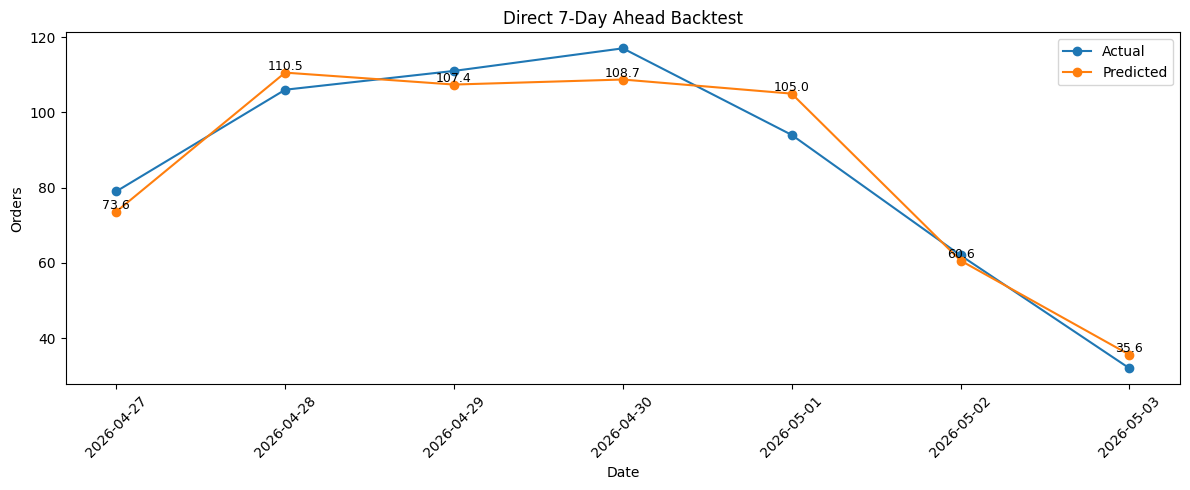

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    compare_backtest.index,
    compare_backtest["Actual_Orders"],
    marker="o",
    label="Actual"
)

plt.plot(
    compare_backtest.index,
    compare_backtest["Predicted_Orders"],
    marker="o",
    label="Predicted"
)

for x, y in zip(compare_backtest.index, compare_backtest["Predicted_Orders"]):
    plt.text(x, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

plt.title("Direct 7-Day Ahead Backtest")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Prediction Intervals

Prediction intervals are estimated using the historical backtest residuals. The 5th and 95th percentiles of the backtest errors are added to the future predictions to create an approximate 90% prediction interval.

This interval gives a practical estimate of uncertainty around the forecast.

In [68]:
compare_backtest["Error"] = (
    compare_backtest["Actual_Orders"] - compare_backtest["Predicted_Orders"]
)

lower_error = compare_backtest["Error"].quantile(0.05)
upper_error = compare_backtest["Error"].quantile(0.95)

print("Lower error:", lower_error)
print("Upper error:", upper_error)

Lower error: -9.039105987548828
Upper error: 7.414625549316404


## 9. Train Final Models on All Available Data

After evaluating the model with backtesting, final models are trained using all available historical data. A separate model is trained for each forecast horizon from 1 day ahead to 7 days ahead.

In [70]:
final_models = {}
final_feature_columns_by_h = {}

for h in range(1, 8):
    temp = add_future_calendar_columns(feat, h, holiday_index)

    # Target: actual orders at t+h
    temp[f"target_h{h}"] = temp["orders"].shift(-h)

    temp = temp.dropna(subset=[f"target_h{h}"]).copy()

    X_all = temp.drop(columns=["orders", f"target_h{h}"])
    y_all = temp[f"target_h{h}"]

    final_feature_columns_by_h[h] = X_all.columns.tolist()

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=5.0,
        reg_lambda=5.0,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_all, y_all)
    final_models[h] = model

print("Final models trained.")

Final models trained.


## 10. Forecast the Next 7 Days

The final models are used to forecast orders for the next 7 days. The prediction intervals estimated from backtest residuals are added to the forecast output.

In [72]:
forecast_origin = feat.index.max()
origin_row = feat.loc[[forecast_origin]].copy()

future_week_forecast = []

for h in range(1, 8):
    X_future = add_future_calendar_columns(origin_row, h, holiday_index)
    X_future = X_future.drop(columns=["orders"], errors="ignore")
    X_future = X_future.reindex(columns=final_feature_columns_by_h[h], fill_value=0)

    pred_date = forecast_origin + pd.Timedelta(days=h)
    pred_orders = final_models[h].predict(X_future)[0]

    future_week_forecast.append((pred_date, pred_orders))

future_week_df = pd.DataFrame(
    future_week_forecast,
    columns=["Date", "Predicted_Orders"]
).set_index("Date")

future_week_df["Lower_90"] = future_week_df["Predicted_Orders"] + lower_error
future_week_df["Upper_90"] = future_week_df["Predicted_Orders"] + upper_error

future_week_df["Lower_90"] = future_week_df["Lower_90"].clip(lower=0)

print(future_week_df)

            Predicted_Orders    Lower_90    Upper_90
Date                                                
2026-05-04        103.962051   94.922943  111.376678
2026-05-05        109.026512   99.987404  116.441139
2026-05-06        105.539146   96.500038  112.953773
2026-05-07        111.101379  102.062271  118.516006
2026-05-08        106.878021   97.838913  114.292648
2026-05-09         65.120781   56.081673   72.535408
2026-05-10         37.952450   28.913343   45.367077


## 11. Forecast Visualization with Prediction Interval

The following plot shows the next 7-day forecast together with an approximate 90% prediction interval.

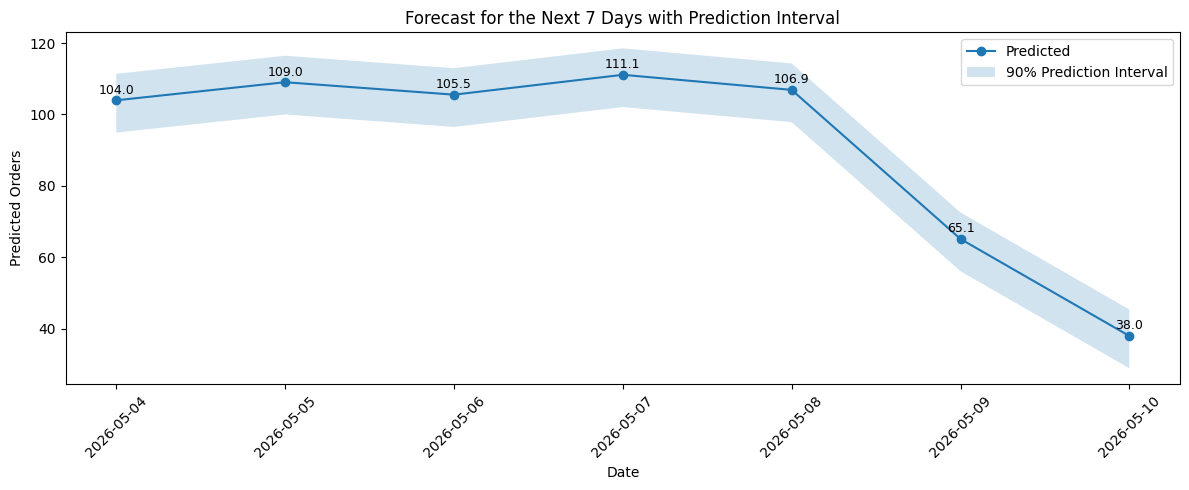

In [74]:
plt.figure(figsize=(12, 5))

plt.plot(
    future_week_df.index,
    future_week_df["Predicted_Orders"],
    marker="o",
    label="Predicted"
)

plt.fill_between(
    future_week_df.index,
    future_week_df["Lower_90"],
    future_week_df["Upper_90"],
    alpha=0.2,
    label="90% Prediction Interval"
)

for x, y in zip(future_week_df.index, future_week_df["Predicted_Orders"]):
    plt.text(
        x,
        y + 1,
        f"{y:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Forecast for the Next 7 Days with Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Predicted Orders")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature importance from XGBoost is used to identify which variables contributed most to the forecast. The feature importance is shown for each forecast horizon.

In [76]:
for h in range(1, 8):
    importance = pd.Series(
        final_models[h].feature_importances_,
        index=final_feature_columns_by_h[h]
    ).sort_values(ascending=False)

    print(f"\n--- Horizon D+{h} ---")
    print(importance.head(15))


--- Horizon D+1 ---
target_is_weekend     0.709122
target_day_of_week    0.176050
is_weekend            0.049132
day_of_week           0.020316
target_is_holiday     0.012843
trend                 0.003244
rolling_mean_28       0.002933
target_dow_sin        0.002861
rolling_max_7         0.002751
rolling_mean_14       0.001943
lag_7                 0.001858
dow_cos               0.001544
lag_5                 0.001045
same_weekday_avg_4    0.000976
rolling_std_7         0.000932
dtype: float32

--- Horizon D+2 ---
dow_cos               0.715558
target_day_of_week    0.129651
day_of_week           0.052527
target_is_holiday     0.028010
rolling_mean_28       0.010606
dow_sin               0.007370
lag_5                 0.006114
trend                 0.005574
rolling_max_7         0.005471
target_dow_sin        0.003126
rolling_mean_14       0.003005
rolling_mean_7        0.002360
lag_3                 0.001903
rolling_std_7         0.001866
month                 0.001383
dtype: float3

### Feature Importance Plot for 1-Day Ahead Forecast

The following plot shows the most important features for the 1-day ahead forecast.

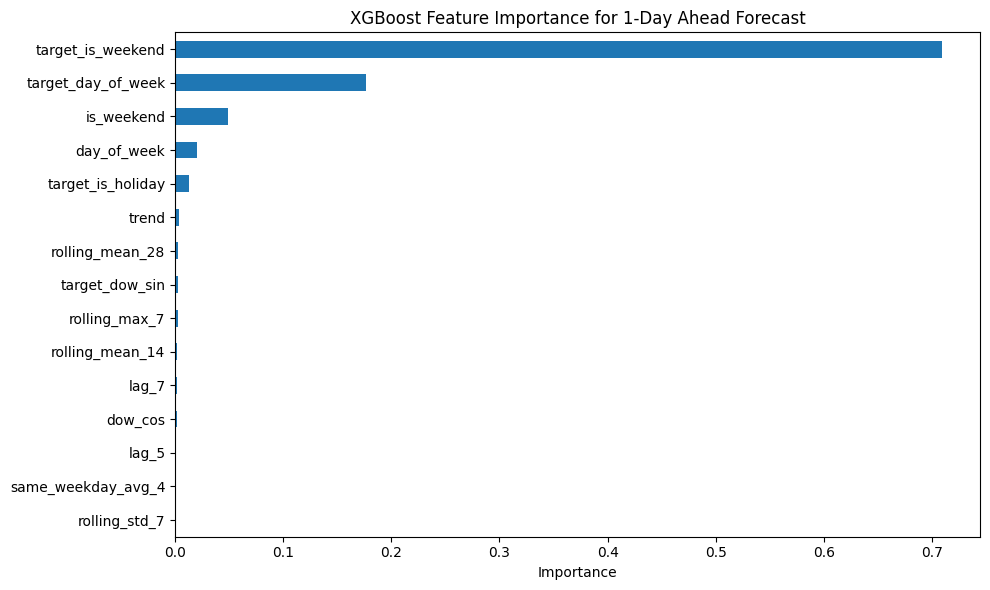

In [78]:
h = 1

importance = pd.Series(
    final_models[h].feature_importances_,
    index=final_feature_columns_by_h[h]
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance for 1-Day Ahead Forecast")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 13. SHAP Model Interpretation

SHAP values are used to interpret the XGBoost forecasting model. The SHAP summary plot shows how each feature affects the prediction for the 1-day ahead forecast.

Positive SHAP values increase the predicted number of orders, while negative SHAP values decrease the predicted number of orders.

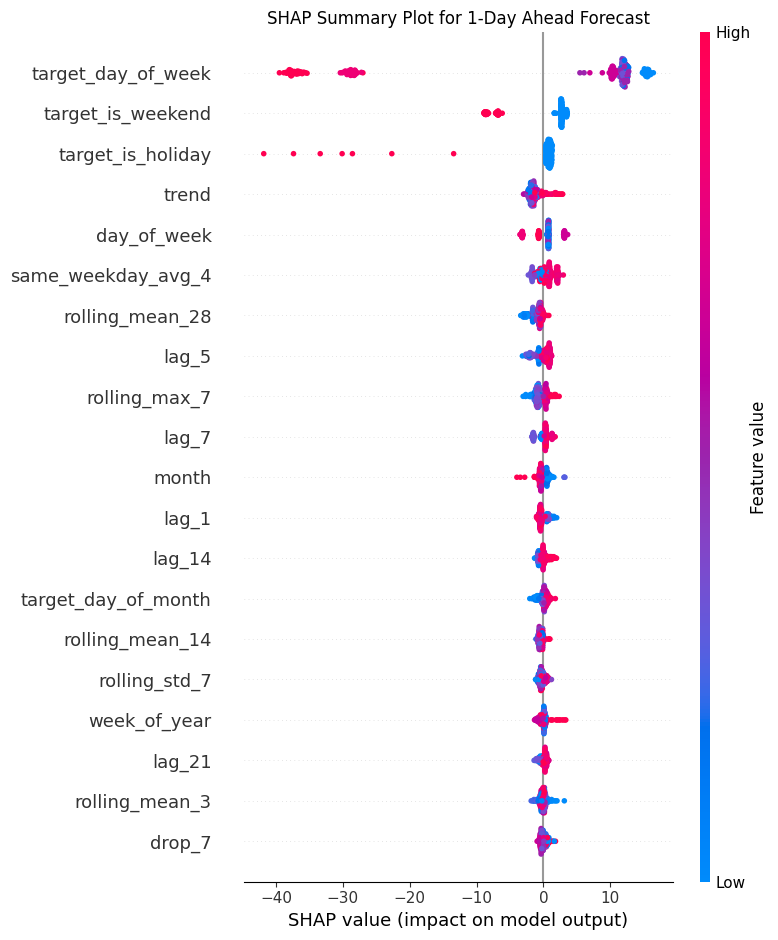

In [80]:
import shap

h = 1

model = final_models[h]
feature_cols = final_feature_columns_by_h[h]

# Recreate the same feature table used to train horizon h
temp = add_future_calendar_columns(feat, h, holiday_index)

# Create the target for horizon h
temp[f"target_h{h}"] = temp["orders"].shift(-h)

# Drop rows where target is missing
temp = temp.dropna(subset=[f"target_h{h}"]).copy()

# Create X using the same columns used during training
X_explain = temp.drop(columns=["orders", f"target_h{h}"])

# Make sure columns match training columns exactly
X_explain = X_explain.reindex(columns=feature_cols, fill_value=0)

# Use only the last 300 rows for faster SHAP calculation
X_explain = X_explain.tail(300)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(
    shap_values,
    X_explain,
    show=False
)

plt.title("SHAP Summary Plot for 1-Day Ahead Forecast")
plt.tight_layout()
plt.show()

### Interpretation of the SHAP Summary Plot

The SHAP summary plot explains how each feature affects the 1-day ahead order forecast. Each point represents one observation from the sample used for interpretation. The horizontal axis shows the SHAP value, which represents the impact of a feature on the model output.

A positive SHAP value increases the predicted number of orders, while a negative SHAP value decreases the predicted number of orders. The color represents the feature value: red indicates a high feature value, and blue indicates a low feature value.

The most influential feature is `target_day_of_week`, which means that the day being forecasted has the strongest effect on the predicted order volume. This confirms that the model relies heavily on weekly seasonality. Some days of the week are associated with higher predicted orders, while others are associated with lower predicted orders.

The features `target_is_weekend` and `target_is_holiday` are also important. Their SHAP values show that weekends and holidays can strongly change the forecast. In this model, some holiday-related observations have large negative SHAP values, meaning that holidays may reduce the expected number of orders.

The `trend` feature also contributes to the prediction, but its effect is smaller than the main calendar variables. Historical demand features such as `same_weekday_avg_4`, `rolling_mean_28`, `lag_5`, `rolling_max_7`, and `lag_7` have smaller but still useful effects. These variables help the model adjust the forecast based on recent order behavior.

Overall, the SHAP results show that the 1-day ahead forecast is mainly driven by calendar effects, especially the target day of week, weekend status, and holiday status, while recent historical order patterns provide additional support for the prediction.

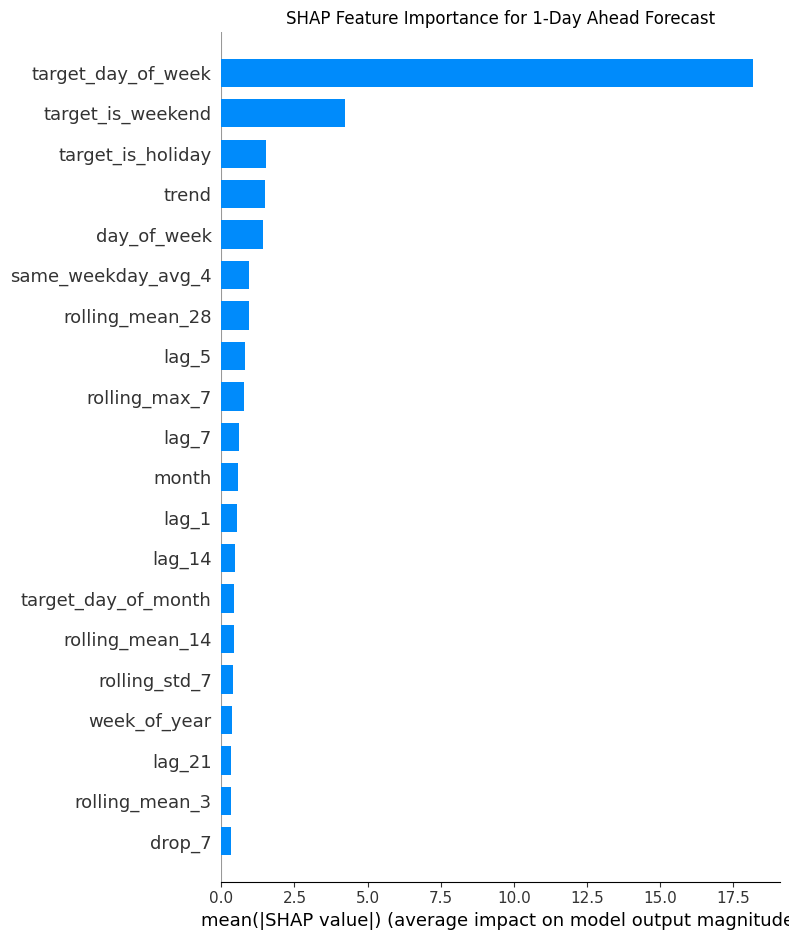

In [82]:
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance for 1-Day Ahead Forecast")
plt.tight_layout()
plt.show()

### Interpretation of the SHAP Feature Importance Plot

The SHAP feature importance plot shows the average absolute SHAP value for each feature. Unlike the SHAP summary plot, this figure does not show whether a feature increases or decreases the forecast. Instead, it shows how strongly each feature influences the model prediction on average.

The results show that `target_day_of_week` is by far the most influential feature for the 1-day ahead forecast. This means that the day being predicted is the main driver of the expected number of orders. The next most important feature is `target_is_weekend`, showing that weekend effects are also important for order forecasting.

The `target_is_holiday` feature also contributes to the prediction, although its average effect is smaller than the day-of-week and weekend indicators. Other features, such as `trend`, `day_of_week`, `same_weekday_avg_4`, `rolling_mean_28`, and lag features, have lower but still useful contributions.

Overall, the plot confirms that the model mainly relies on calendar-related features, especially the forecasted day of week and weekend status, while historical order features provide additional support.

## 14. Conclusion

This project shows how a short-term demand forecasting model can be built from a simple two-column dataset using feature engineering and XGBoost regression. The model uses calendar features, lag values, rolling statistics, holiday indicators, trend features, and cyclical encodings to forecast future daily orders.

The model was evaluated using a 7-day holdout backtest. Prediction intervals were added to represent uncertainty around the forecast. SHAP values were also used to interpret the model and identify the most influential features.

The results show that calendar-related variables, especially the target day of week and weekend indicators, have a strong effect on the forecast. Historical order patterns, such as lag and rolling features, also contribute to the prediction.

Future improvements could include additional business variables such as promotions, weather, marketing campaigns, pricing, stock availability, delivery delays, and special events.